In [1]:
import tensorly as tl

tl.get_backend()

'numpy'

In [2]:
from hoda.hoda import HODA
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from mne.decoding import Scaler
import numpy as np
from sklearn.pipeline import Pipeline
from hoda.hoda import BTTDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


hoda_params = dict(
    max_iter=128,
    tol=1e-8,
    init ='svd',
    shrinkage='lw',
    toeplitz=None,
    obj='tr',
    solver='lanczos',
    taper=False,
    extra_train_info=False,
    verbose=True,
)

bttda_params = dict(
    verbose=True,
    forward=False,
    extra_train_info=False
)

clf = Pipeline([
    ('numpy', FunctionTransformer(tl.to_numpy)),
    ('scaler2', StandardScaler()),
    ('clf', LDA(shrinkage='auto', solver='lsqr'))
])
deltas = [0] + list(np.geomspace(1e-3,1, 5-1))
clf

Pipeline(steps=[('numpy',
                 FunctionTransformer(func=<function NumpyBackend.to_numpy at 0x14e20c777240>)),
                ('scaler2', StandardScaler()),
                ('clf',
                 LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'))])

In [11]:
from moabb.paradigms import P300
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation
from sklearn.model_selection import StratifiedKFold, GridSearchCV

sfreq = 48
paradigm = P300(resample=sfreq)
datasets = [BNCI2014_008()]

grid_delta = [0,1e-3, 1e-2, 1e-1,  0.5]
#grid_delta = [0.01]
grid_n_blocks = [ 1, 2,3,4,5,6,7,8,9,10]

cv = StratifiedKFold(n_splits=5)

In [12]:
import pandas as pd
import tensorly as tl
from sklearn.metrics import roc_auc_score

results = []

for dataset in datasets:
    for subject in dataset.subject_list[:1]:
        data, labels, meta = paradigm.get_data(dataset=dataset, subjects=[subject])
        X = tl.tensor(data)
        y = labels
        for delta in grid_delta:
            print(delta)
            hoda_params['delta'] = delta
            bttda = BTTDA(
                ranks=[None]*max(grid_n_blocks),
                hoda_params=hoda_params
            )            
            for fold, (train_idc, test_idc) in enumerate(cv.split(X, y)):
                bttda.fit(X[train_idc], y[train_idc])
                for n_blocks in grid_n_blocks:
                    Xt = bttda.transform(X, n_blocks=n_blocks)
                    clf.fit(Xt[train_idc], y[train_idc])
                    y_proba_pred = clf.predict_proba(Xt)
                    res = dict(
                        subject = subject,
                        dataset = dataset.code,
                        fold = fold,
                        delta=delta,
                        n_blocks=n_blocks,
                        train_roc_auc = roc_auc_score(y[train_idc], y_proba_pred[train_idc,1]),
                        test_roc_auc = roc_auc_score(y[test_idc], y_proba_pred[test_idc,1]),
                    )
                    results.append(res)

results = pd.DataFrame(results)

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 4200 events (all good), 0 – 1 s (baseline off), ~65.9 MB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")
Forward model :  64%|██████▍   | 82/128 [00:00<00:00, 263.79it/s]


ValueError: delta should lie in [0, 1)

In [15]:
results

,subject,dataset,fold,delta,n_blocks,train_roc_auc,test_roc_auc
0,1,BNCI2014-008,0,0.001,1,0.889906,0.795939
1,1,BNCI2014-008,0,0.001,2,0.914562,0.791429
2,1,BNCI2014-008,0,0.001,3,0.914547,0.790061
3,1,BNCI2014-008,0,0.001,4,0.914903,0.788418
4,1,BNCI2014-008,0,0.001,5,0.915177,0.788245
...,...,...,...,...,...,...,...
195,1,BNCI2014-008,4,0.500,6,0.871469,0.846816
196,1,BNCI2014-008,4,0.500,7,0.871943,0.847286
197,1,BNCI2014-008,4,0.500,8,0.880341,0.853398
198,1,BNCI2014-008,4,0.500,9,0.880651,0.854786


<Axes: xlabel='n_blocks', ylabel='test_roc_auc'>

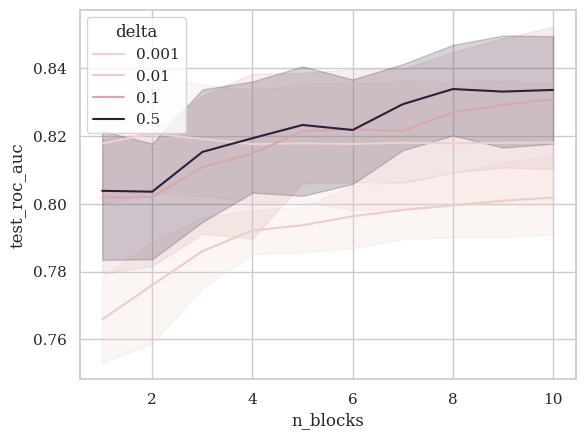

In [18]:
import seaborn as sns
sns.lineplot(data=results, x='n_blocks', y='test_roc_auc', hue='delta', errorbar=None)